In [13]:
import requests
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# 1. Descarga de los datos biológicos
fileurl = "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE223351&format=file&file=GSE223351%5FMMTV%2DErbb2%5FRawCounts%2Exlsx"
filename = "GSE223351.xlsx"
response = requests.get(fileurl)
with open(filename, "wb") as f:
    f.write(response.content)

In [15]:
# 2. Cargar los datos
df = pd.read_excel('../Data/GSE223351.xlsx')

In [16]:
# 3. Limpieza de valores únicos
def make_unique(names):
    seen = {}
    result = []
    for name in names:
        if name not in seen:
            seen[name] = 0
            result.append(name)
        else:
            seen[name] += 1
            result.append(f"{name}.{seen[name]}")
    return result

In [17]:
df.index = make_unique(df.iloc[:,0].astype(str))
df = df.iloc[:,1:]

In [18]:
# 4. TPM normalización
sizes = df.sum(axis=0)
tpm = df.div(sizes, axis=1) * 1e6
tpm_log2 = np.log2(tpm + 1)

In [19]:
# 5. Filtrado de varianza > 0
gene_variance = tpm_log2.var(axis=1)
tpm_filtered = tpm_log2[gene_variance > 0]

In [20]:
# 6. Grupos
grupos = ["Control","Control","Control","Metastasis","Metastasis","Metastasis"]

In [21]:
# 7. Welch t-test por cada gen
p_values = []
for gene, row in tpm_filtered.iterrows():
    x = row.values
    ctrl = x[np.array(grupos)=="Control"]
    met  = x[np.array(grupos)=="Metastasis"]
    try:
        pv = ttest_ind(met, ctrl, equal_var=False).pvalue
    except:
        pv = np.nan
        p_values.append(pv)
    p_values = np.array(p_values)

In [22]:
# 8. Calculo de FoldChange (Log2FC)
log2FC = []
for gene, row in tpm_filtered.iterrows():
    x = row.values
    fc = np.mean(x[np.array(grupos)=="Metastasis"]) - np.mean(x[np.array(grupos)=="Control"])
    log2FC.append(fc)
log2FC = np.array(log2FC)

In [23]:
genes = tpm_filtered.index
mat = tpm_filtered.values
group_array = np.array(grupos)

# p-values
p_values = []
log2FC = []

for row in mat:
    ctrl = row[group_array == "Control"]
    met  = row[group_array == "Metastasis"]

    # t-test
    try:
        pv = ttest_ind(met, ctrl, equal_var=False).pvalue
    except:
        pv = np.nan
    p_values.append(pv)

    # log2FC
    fc = np.mean(met) - np.mean(ctrl)
    log2FC.append(fc)

p_values = np.array(p_values)
log2FC = np.array(log2FC)


In [24]:
# 9. Tabla de Resultados
results = pd.DataFrame({
    "Gene": tpm_filtered.index,
    "log2FC": log2FC,
    "p_values": p_values
})

In [25]:
# 10. Adjuste de p-values (FDR)
results["Adj_p"] = multipletests(results["p_values"], method='fdr_bh')[1]

In [26]:
# 11. Clasificación
umbral_fc = 1
alpha = 0.05
def classify(row):
    if row["Adj_p"]<alpha and row["log2FC"]>umbral_fc:
        return "Sobreexpresado"
    if row["Adj_p"]<alpha and row["log2FC"]<-umbral_fc:
        return "Subexpresado"
    return "No Significativo"
results["Clasificacion"] = results.apply(classify, axis=1)

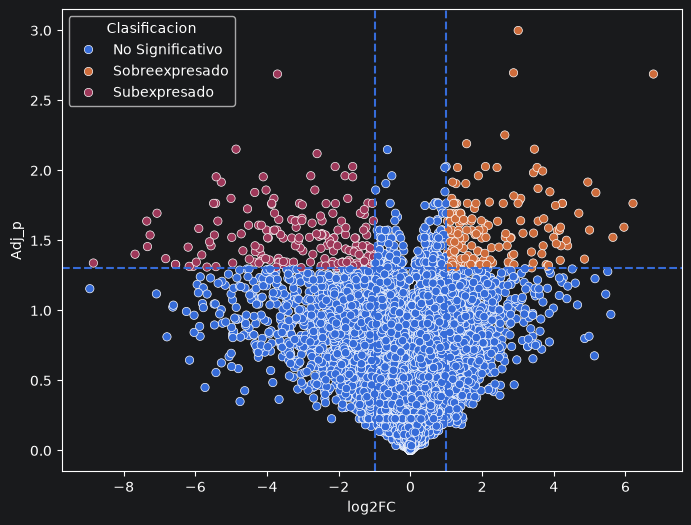

In [27]:
# 12. Volcano plot

plt.figure(figsize = (8,6))
sns.scatterplot(data=results, x="log2FC", y=-np.log10(results["Adj_p"]), hue="Clasificacion")
plt.axvline(-umbral_fc, linestyle="--")
plt.axvline(umbral_fc, linestyle="--")
plt.axhline(-np.log10(alpha), linestyle="--")
plt.savefig("volcano_plot.png", dpi=300)

In [28]:
# 13. Genes top
top_genes = results[results["Clasificacion"]!="NS"].sort_values("Adj_p").head(20)
print(top_genes)

                Gene    log2FC      p_values     Adj_p     Clasificacion
10774           Mira  3.006858  5.223401e-08  0.001002    Sobreexpresado
8318           Hoxa7  2.876389  2.094231e-07  0.002009    Sobreexpresado
8130           Hgfac  6.779529  4.275592e-07  0.002050    Sobreexpresado
17666        Tspan17 -3.709279  3.851440e-07  0.002050      Subexpresado
536    3300005D01Rik  2.633463  1.456152e-06  0.005587    Sobreexpresado
13450          Prox2  1.567023  2.015429e-06  0.006444    Sobreexpresado
6002        Fam171a1  3.459737  2.940694e-06  0.007051    Sobreexpresado
13146           Pon3 -4.864964  2.841571e-06  0.007051      Subexpresado
3829           Chmp7 -0.640277  3.332476e-06  0.007103  No Significativo
15118          Sgsm1 -2.604117  3.953406e-06  0.007584      Subexpresado
8795          Iqgap1 -2.099792  6.848427e-06  0.009384      Subexpresado
12918         Plagl1  0.996289  6.599188e-06  0.009384  No Significativo
16711           Tchh  2.094165  6.791663e-06  0.009

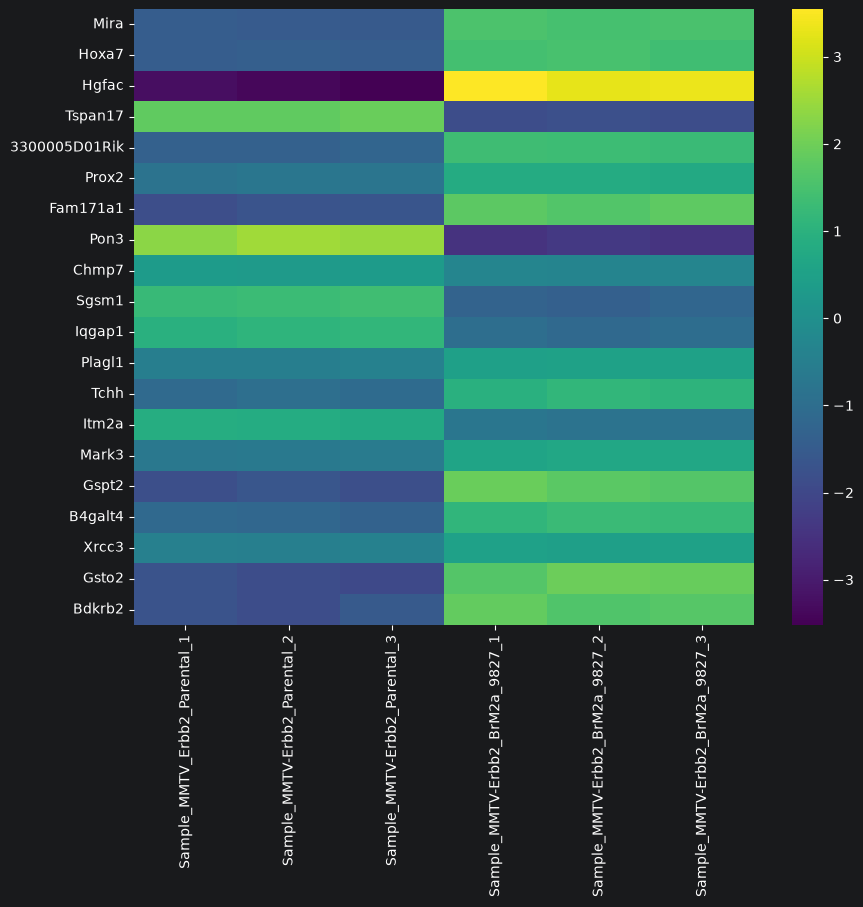

In [29]:
# 14. Heatmap
matriz_top = tpm_filtered.loc[top_genes["Gene"]]
heatmap_data = (matriz_top.T - matriz_top.mean(axis=1)).T
plt.figure(figsize = (10,8))
sns.heatmap(heatmap_data, cmap="viridis")
plt.savefig("heatmap_topgenes.png", dpi=300)